# Simple linear regression

This notebook walks through the essentials of simple linear regression

$$Y_i = \beta_0 + \beta_1 x_i + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0, \sigma^2) \ \text{i.i.d.}$$

on four small, classic datasets. Each one highlights a different idea:

1. **Anscombe's quartet**: why summary statistics are never enough and you should always plot the data.
2. **Antique clocks**: fitting and interpreting a first model.
3. **Windmill**: transforming the predictor so the relationship becomes linear, plus confidence and prediction intervals.
4. **Forbes' boiling point data**: detecting an outlier and measuring how much it affects the fit.

The last section uses a Monte Carlo simulation to check that the least squares estimates behave as theory predicts.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
import warnings

warnings.filterwarnings("ignore", message="kurtosistest only valid")
plt.rcParams["figure.dpi"] = 100

## 1. Anscombe's quartet: always look at the data

Anscombe's quartet is made of four datasets of eleven points each. For every dataset we fit a least squares line and collect the intercept, the slope, their standard errors and the residual standard error $\hat\sigma$.

In [2]:
anscombe = pd.read_csv("data/anscombe.csv", index_col=0)

rows = {}
for k in range(1, 5):
    fit = sm.OLS(anscombe[f"y{k}"], sm.add_constant(anscombe[f"x{k}"])).fit()
    rows[f"dataset {k}"] = {
        "intercept": fit.params["const"],
        "se(intercept)": fit.bse["const"],
        "slope": fit.params[f"x{k}"],
        "se(slope)": fit.bse[f"x{k}"],
        "sigma_hat": np.sqrt(fit.scale),
        "R2": fit.rsquared,
    }
summary = pd.DataFrame(rows).round(3)
summary

,dataset 1,dataset 2,dataset 3,dataset 4
intercept,3.000,3.001,3.002,3.002
se(intercept),1.125,1.125,1.124,1.124
slope,0.500,0.500,0.500,0.500
se(slope),0.118,0.118,0.118,0.118
sigma_hat,1.237,1.237,1.236,1.236
R2,0.667,0.666,0.666,0.667


The four fits are practically identical: same intercept (≈ 3.0), same slope (≈ 0.5), same $\hat\sigma$ and same $R^2$. Judging from the numbers alone, we would conclude that the four datasets describe the same relationship. The plots tell a very different story.

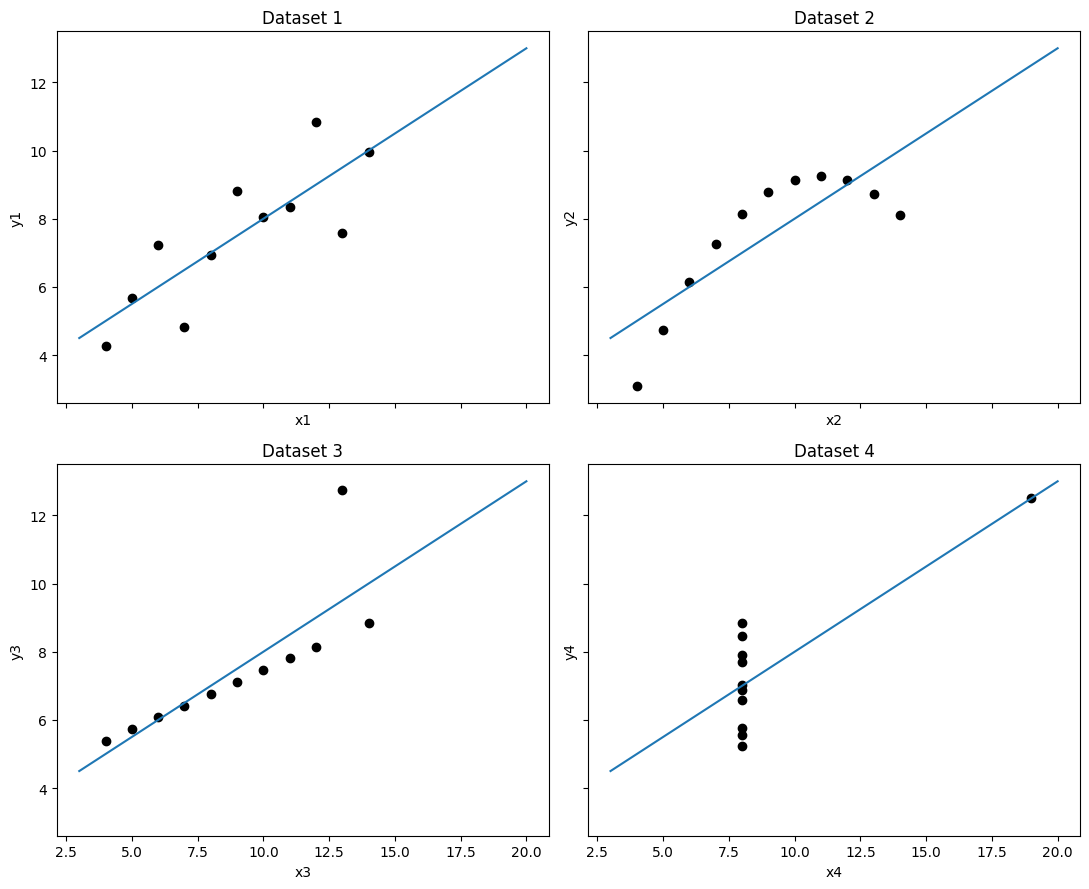

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)
grid = np.linspace(3, 20, 100)
for k, ax in enumerate(axes.flat, start=1):
    ax.scatter(anscombe[f"x{k}"], anscombe[f"y{k}"], color="black")
    ax.plot(grid, summary.loc["intercept", f"dataset {k}"] + summary.loc["slope", f"dataset {k}"] * grid, color="tab:blue")
    ax.set(title=f"Dataset {k}", xlabel=f"x{k}", ylabel=f"y{k}")
fig.tight_layout()
plt.show()

- **Dataset 1** is what a linear model is designed for: a linear trend with random noise.
- **Dataset 2** follows a smooth curve, so a straight line is the wrong functional form.
- **Dataset 3** is perfectly linear except for one outlier, which tilts the line.
- **Dataset 4** has a constant $x$ except for one point: that single observation alone determines the slope.

**Takeaway:** coefficients, standard errors and $R^2$ only describe the model's fit, not whether the model makes sense. A graphical check is essential.

## 2. A first model: the price of antique clocks

The dataset contains the age (in years) and the auction price of 32 antique clocks. Does the price grow with age, and by how much?

In [4]:
clocks = pd.read_csv("data/antique_clocks.csv", index_col=0)
print(clocks.shape)
clocks.describe().round(1)

(32, 2)


,age,price
count,32.0,32.0
mean,144.9,1327.2
std,27.4,393.1
min,108.0,729.0
25%,117.0,1053.0
50%,140.0,1257.5
75%,168.5,1560.8
max,194.0,2131.0


In [5]:
clock_fit = sm.OLS(clocks["price"], sm.add_constant(clocks["age"])).fit()
print(clock_fit.summary().tables[1])
print(f"Residual standard error: {np.sqrt(clock_fit.scale):.1f} on {int(clock_fit.df_resid)} degrees of freedom")
print(f"R-squared: {clock_fit.rsquared:.3f}")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -191.6576    263.887     -0.726      0.473    -730.586     347.271
age           10.4791      1.790      5.854      0.000       6.823      14.135
Residual standard error: 273.0 on 30 degrees of freedom
R-squared: 0.533


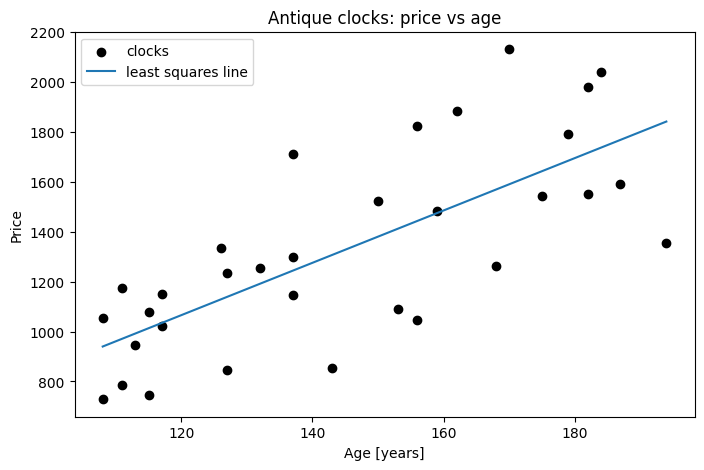

In [6]:
grid = np.linspace(clocks["age"].min(), clocks["age"].max(), 100)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(clocks["age"], clocks["price"], color="black", label="clocks")
ax.plot(grid, clock_fit.params["const"] + clock_fit.params["age"] * grid, color="tab:blue", label="least squares line")
ax.set(xlabel="Age [years]", ylabel="Price", title="Antique clocks: price vs age")
ax.legend()
plt.show()

The prices vary a lot, but the trend is clearly increasing: on average every additional year of age adds about **10.5** to the auction price, and the slope is highly significant (p < 0.001).

Still, age explains only about half of the variability ($R^2 \approx 0.53$) and the residual standard error is large (≈ 273). Age alone is not enough to price a clock precisely: other factors matter, such as the number of bidders.

## 3. Transforming the predictor: windmill power

An engineer measured the direct current (in ampere) produced by a windmill at 25 different wind speeds (in m/s).

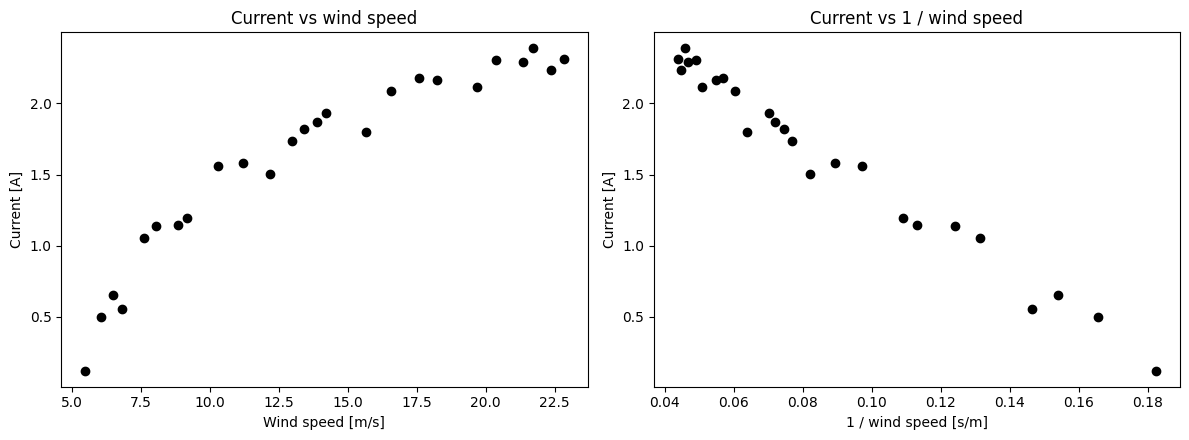

In [7]:
windmill = pd.read_csv("data/windmill.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.scatter(windmill["wind_speed"], windmill["current"], color="black")
ax1.set(xlabel="Wind speed [m/s]", ylabel="Current [A]", title="Current vs wind speed")
ax2.scatter(1 / windmill["wind_speed"], windmill["current"], color="black")
ax2.set(xlabel="1 / wind speed [s/m]", ylabel="Current [A]", title="Current vs 1 / wind speed")
fig.tight_layout()
plt.show()

In the original scale the relationship flattens out at high speeds: the windmill cannot produce more than a certain current. Using the reciprocal $1/x$ as predictor straightens the cloud of points, so we fit

$$\text{current} = \beta_0 + \beta_1 \cdot \frac{1}{\text{wind speed}} + \varepsilon .$$

In [8]:
X_wind = sm.add_constant(pd.DataFrame({"inv_speed": 1 / windmill["wind_speed"]}))
wind_fit = sm.OLS(windmill["current"], X_wind).fit()
print(wind_fit.summary().tables[1])
print(f"R-squared: {wind_fit.rsquared:.3f}")
print("\n99% confidence interval for the coefficients:")
print(wind_fit.conf_int(alpha=0.01).rename(columns={0: "lower", 1: "upper"}).round(3))

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9789      0.045     66.341      0.000       2.886       3.072
inv_speed    -15.5155      0.462    -33.592      0.000     -16.471     -14.560
R-squared: 0.980

99% confidence interval for the coefficients:
            lower   upper
const       2.853   3.105
inv_speed -16.812 -14.219


The fit is very good ($R^2 \approx 0.98$). The coefficients also have a physical meaning once we go back to the original scale:

- when the wind speed goes to infinity, $1/x \to 0$ and the current approaches $\beta_0$: **$\hat\beta_0 \approx 2.98$ A is the maximum current** the windmill can produce;
- setting the current to zero gives $x = -\beta_1 / \beta_0$: **the minimum wind speed (≈ 5.2 m/s)** needed to start producing power.

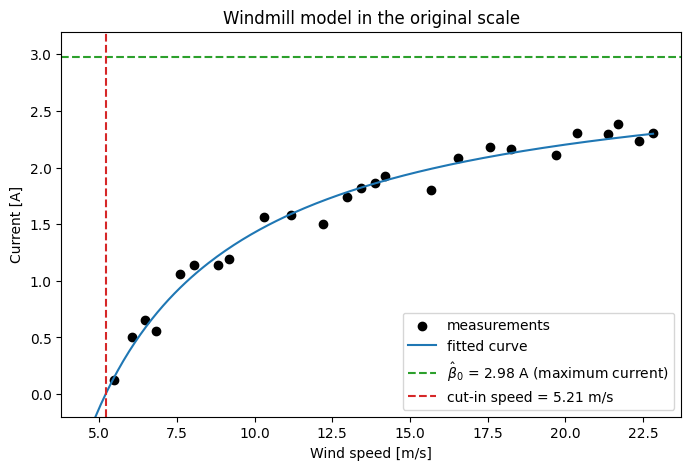

In [9]:
b0, b1 = wind_fit.params["const"], wind_fit.params["inv_speed"]
cut_in = -b1 / b0
speed = np.linspace(cut_in * 0.9, windmill["wind_speed"].max(), 200)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(windmill["wind_speed"], windmill["current"], color="black", label="measurements")
ax.plot(speed, b0 + b1 / speed, color="tab:blue", label="fitted curve")
ax.axhline(b0, ls="--", color="tab:green", label=rf"$\hat\beta_0$ = {b0:.2f} A (maximum current)")
ax.axvline(cut_in, ls="--", color="tab:red", label=f"cut-in speed = {cut_in:.2f} m/s")
ax.set(xlabel="Wind speed [m/s]", ylabel="Current [A]", ylim=(-0.2, 3.2), title="Windmill model in the original scale")
ax.legend()
plt.show()

### Confidence vs prediction intervals

We compute the expected current at wind speeds of 1 m/s and 10 m/s, with a 95% **confidence interval** (uncertainty about the mean current) and a 95% **prediction interval** (uncertainty about a single new measurement).

In [10]:
new = sm.add_constant(pd.DataFrame({"inv_speed": [1 / 1, 1 / 10]}), has_constant="add")
pred = wind_fit.get_prediction(new).summary_frame(alpha=0.05)
pred.index = ["1 m/s", "10 m/s"]
pred[["mean", "mean_ci_lower", "mean_ci_upper", "obs_ci_lower", "obs_ci_upper"]].round(3)

,mean,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
1 m/s,-12.537,-13.409,-11.665,-13.430,-11.643
10 m/s,1.427,1.387,1.468,1.228,1.626


- At **10 m/s** the model predicts 1.43 A. As expected, the prediction interval is wider than the confidence interval, because it also includes the noise of a single measurement.
- At **1 m/s** the model predicts a *negative* current of −12.5 A, which is physically meaningless. 1 m/s is far below the cut-in speed and far outside the range of the data (the minimum measured speed is about 6 m/s).

**Takeaway:** a regression model is only reliable inside the range of the data it was fitted on. Extrapolating can produce nonsense, even when the fit is excellent.

## 4. Outliers and influence: Forbes' boiling point data

In the 1850s the physicist James D. Forbes studied how the boiling point of water (°F) depends on air pressure (inches of mercury), so that altitude could be estimated with just a thermometer. The data contain 17 measurements taken in the Alps and in Scotland.

Theory suggests a linear relation between the boiling point and the **logarithm** of the pressure, so we use $x = 100 \cdot \log(\text{pressure})$.

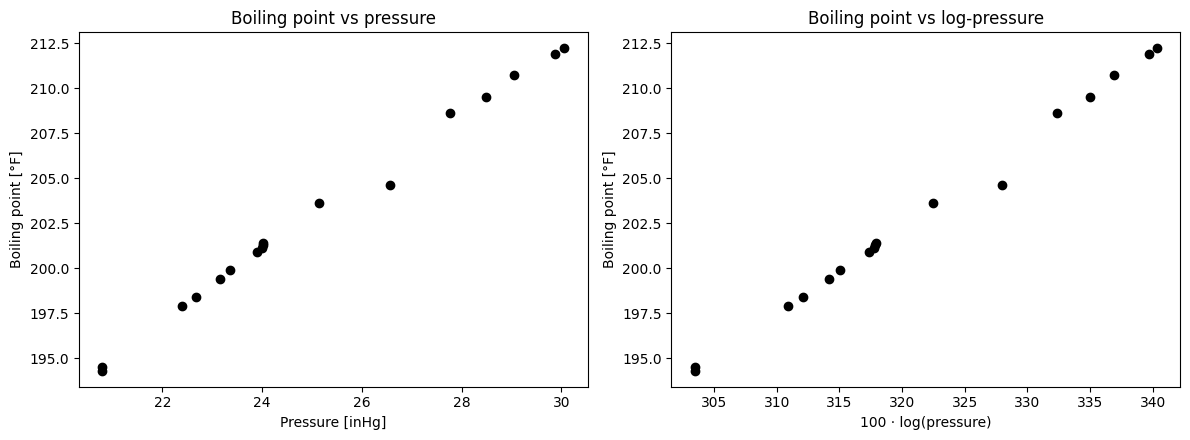

In [11]:
forbes = pd.read_csv("data/Forbes.csv")
forbes["x"] = 100 * np.log(forbes["pressure"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.scatter(forbes["pressure"], forbes["y"], color="black")
ax1.set(xlabel="Pressure [inHg]", ylabel="Boiling point [°F]", title="Boiling point vs pressure")
ax2.scatter(forbes["x"], forbes["y"], color="black")
ax2.set(xlabel="100 · log(pressure)", ylabel="Boiling point [°F]", title="Boiling point vs log-pressure")
fig.tight_layout()
plt.show()

On the original scale the points lie on a slightly curved line; after the log transformation they follow a straight line almost perfectly. Let us fit the model and look at the residuals.

In [12]:
forbes_fit = sm.OLS(forbes["y"], sm.add_constant(forbes[["x"]])).fit()
print(forbes_fit.summary().tables[1])

influence = forbes_fit.get_influence().summary_frame()
influence[["standard_resid", "hat_diag", "cooks_d"]].round(3).sort_values("standard_resid", key=abs, ascending=False).head(5)

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         47.8638      2.852     16.784      0.000      41.786      53.942
x              0.4825      0.009     54.420      0.000       0.464       0.501


,standard_resid,hat_diag,cooks_d
11,-3.705,0.078,0.577
13,0.964,0.111,0.058
14,0.800,0.164,0.063
0,0.617,0.202,0.048
10,0.407,0.059,0.005


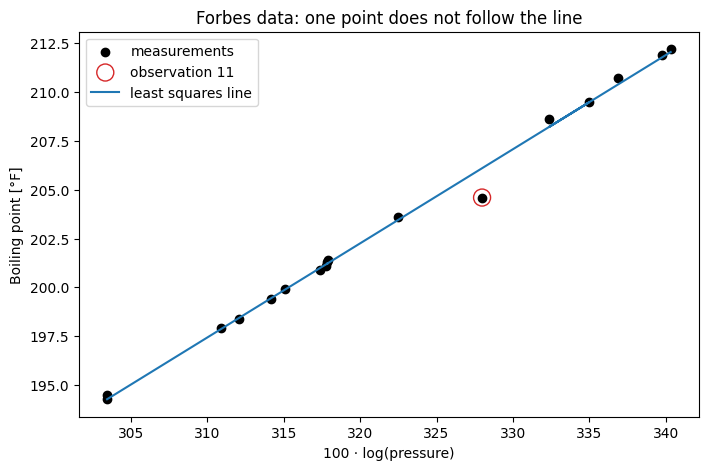

In [13]:
outlier = influence["standard_resid"].abs().idxmax()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(forbes["x"], forbes["y"], color="black", label="measurements")
ax.scatter(forbes.loc[outlier, "x"], forbes.loc[outlier, "y"], s=150, facecolors="none", edgecolors="tab:red", label=f"observation {outlier}")
ax.plot(forbes["x"], forbes_fit.fittedvalues, color="tab:blue", label="least squares line")
ax.set(xlabel="100 · log(pressure)", ylabel="Boiling point [°F]", title="Forbes data: one point does not follow the line")
ax.legend()
plt.show()

Observation 11 (the 12th measurement) has a standardized residual of about −3.7: it lies far from the line followed by all the other points, probably because of a measurement or transcription error. Let us refit the model without it and compare.

In [14]:
clean = forbes.drop(index=outlier)
clean_fit = sm.OLS(clean["y"], sm.add_constant(clean[["x"]])).fit()

comparison = pd.DataFrame({
    "all data": [*forbes_fit.params, *forbes_fit.bse, np.sqrt(forbes_fit.scale)],
    "without outlier": [*clean_fit.params, *clean_fit.bse, np.sqrt(clean_fit.scale)],
}, index=["beta0", "beta1", "se(beta0)", "se(beta1)", "sigma_hat"])
comparison["ratio"] = comparison["all data"] / comparison["without outlier"]
comparison.round(4)

,all data,without outlier,ratio
beta0,47.8638,46.4530,1.0304
beta1,0.4825,0.4872,0.9904
se(beta0),2.8517,0.8683,3.2842
se(beta1),0.0089,0.0027,3.2801
sigma_hat,0.4223,0.1274,3.3133


The coefficients barely move, because the outlier lies in the middle of the $x$ range and has low leverage. What changes dramatically is the **uncertainty**: the residual standard error and the standard errors of the coefficients shrink by a factor of about 3. A single bad point was inflating all the inference.

With the clean model, the test $H_0: \beta_1 = 0$ is rejected with an extremely small p-value, and the slope is estimated very precisely:

In [15]:
print(f"p-value of the slope: {clean_fit.pvalues['x']:.2e}")
print(clean_fit.conf_int(alpha=0.05).rename(columns={0: "2.5%", 1: "97.5%"}).round(3))

p-value of the slope: 5.77e-25
         2.5%   97.5%
const  44.591  48.315
x       0.481   0.493


Finally, the expected boiling point at a pressure of 26 inHg, i.e. $x_0 = 100 \cdot \log(26) \approx 325.81$:

In [16]:
x0 = sm.add_constant(pd.DataFrame({"x": [100 * np.log(26)]}), has_constant="add")
for level in (0.95, 0.99):
    frame = clean_fit.get_prediction(x0).summary_frame(alpha=1 - level)
    print(f"{level:.0%} CI for E[Y | x0]: {frame['mean'].iloc[0]:.3f} °F  "
          f"[{frame['mean_ci_lower'].iloc[0]:.3f}, {frame['mean_ci_upper'].iloc[0]:.3f}]")

95% CI for E[Y | x0]: 205.172 °F  [205.099, 205.246]
99% CI for E[Y | x0]: 205.172 °F  [205.070, 205.275]


## 5. How reliable are the estimates? A Monte Carlo check

The standard errors reported by `statsmodels` come from theory. We can verify them by simulation: we fix the design points $x_i$, generate many datasets from a known model

$$Y_i = 4 + 2 x_i + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0, 2),$$

fit a regression on each one and look at the distribution of the estimates. Theory says that $\hat\beta_0$ and $\hat\beta_1$ are normally distributed around the true values, with standard errors

$$se(\hat\beta_1) = \sqrt{\frac{\sigma^2}{SS_x}}, \qquad se(\hat\beta_0) = \sqrt{\sigma^2 \left(\frac{1}{n} + \frac{\bar x^2}{SS_x}\right)}, \qquad SS_x = \sum_i (x_i - \bar x)^2 .$$

In [17]:
rng = np.random.default_rng(0)
n_sim = 100_000
x_i = np.array([0, 3, 4, 8, 10, 11, 13, 16, 17, 20])
X = sm.add_constant(x_i)
sigma2 = 2

# Each column of Y is one simulated dataset; one least squares solve fits all of them at once.
Y = (4 + 2 * x_i)[:, None] + rng.normal(0, np.sqrt(sigma2), size=(len(x_i), n_sim))
betas = np.linalg.lstsq(X, Y, rcond=None)[0]
b0_hat, b1_hat = betas
print(f"{n_sim:,} simulated datasets fitted")

100,000 simulated datasets fitted


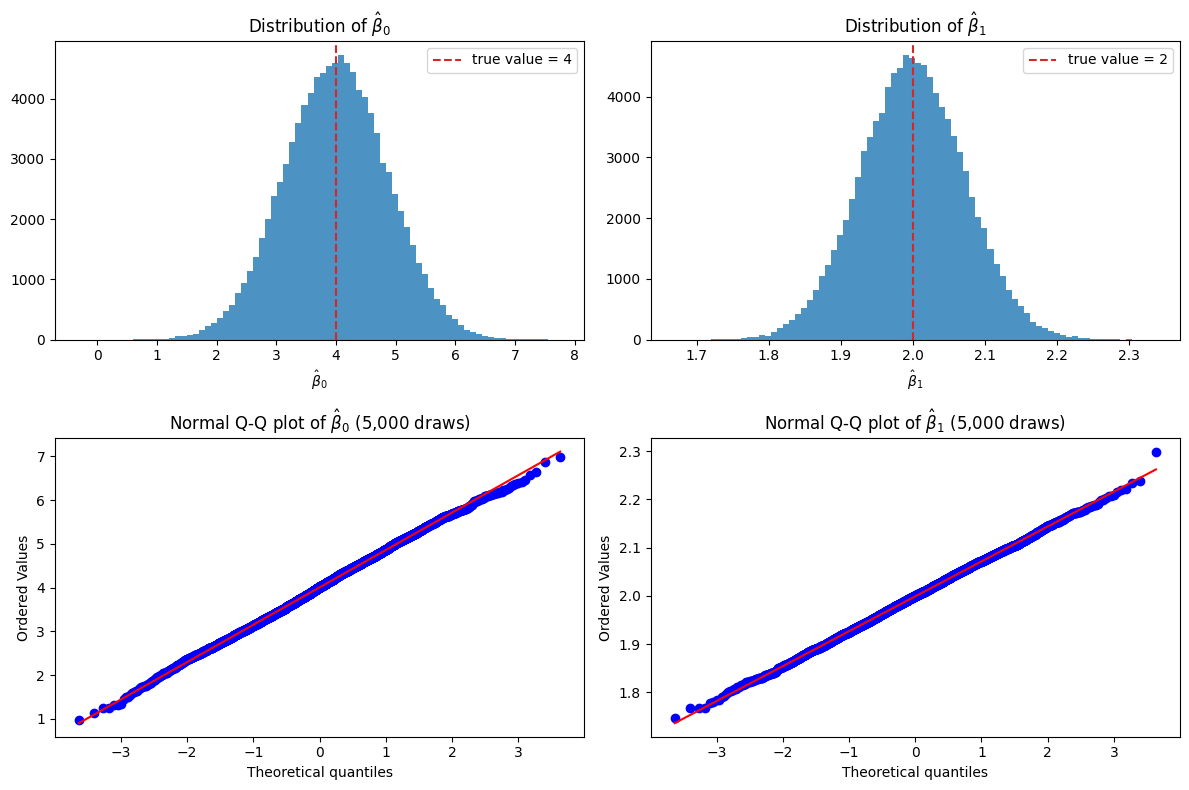

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for col, (est, name, true) in enumerate([(b0_hat, r"$\hat\beta_0$", 4), (b1_hat, r"$\hat\beta_1$", 2)]):
    axes[0, col].hist(est, bins=80, color="tab:blue", alpha=0.8)
    axes[0, col].axvline(true, color="tab:red", ls="--", label=f"true value = {true}")
    axes[0, col].set(title=f"Distribution of {name}", xlabel=name)
    axes[0, col].legend()
    stats.probplot(est[:5000], dist="norm", plot=axes[1, col])
    axes[1, col].set_title(f"Normal Q-Q plot of {name} (5,000 draws)")
fig.tight_layout()
plt.show()

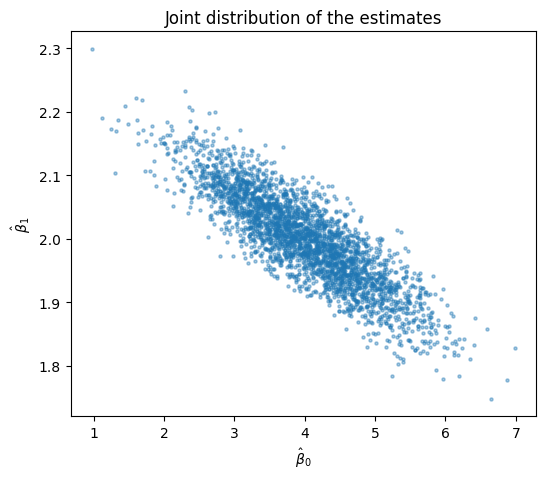

Correlation between the two estimates: -0.856


In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(b0_hat[:3000], b1_hat[:3000], s=5, alpha=0.4)
ax.set(xlabel=r"$\hat\beta_0$", ylabel=r"$\hat\beta_1$", title="Joint distribution of the estimates")
plt.show()
print(f"Correlation between the two estimates: {np.corrcoef(b0_hat, b1_hat)[0, 1]:.3f}")

Both estimates are normally distributed and centred on the true values. They are also strongly **negatively correlated**: since all $x_i \ge 0$, a line that happens to be steeper has to cross the y-axis lower to pass through the same cloud of points.

Finally, we compare the empirical spread of the estimates with the theoretical standard errors:

In [20]:
ss_x = np.sum((x_i - x_i.mean()) ** 2)
theory = {
    "beta0": np.sqrt(sigma2 * (1 / len(x_i) + x_i.mean() ** 2 / ss_x)),
    "beta1": np.sqrt(sigma2 / ss_x),
}
pd.DataFrame({
    "true value": [4, 2],
    "mean of estimates": [b0_hat.mean(), b1_hat.mean()],
    "empirical std": [b0_hat.std(), b1_hat.std()],
    "theoretical se": [theory["beta0"], theory["beta1"]],
}, index=["beta0", "beta1"]).round(4)

,true value,mean of estimates,empirical std,theoretical se
beta0,4,4.0012,0.8602,0.8616
beta1,2,2.0000,0.0722,0.0722


The simulation matches theory: the estimates are unbiased, and their empirical standard deviations (≈ 0.86 and ≈ 0.072) coincide with the theoretical standard errors.

## Summary

- Always **plot** the data: identical regression output can hide completely different patterns (Anscombe).
- A **transformation** of the predictor can turn a non-linear relationship into a linear one, and the coefficients often keep a physical meaning (windmill).
- **Prediction intervals** are wider than confidence intervals, and neither is meaningful outside the range of the data.
- A single **outlier** can inflate the residual standard error and every standard error derived from it (Forbes).
- Under the model assumptions the least squares estimates are **unbiased and normally distributed**, with exactly the standard errors theory predicts.